In [1]:
import matplotlib.pyplot as plt
import numpy
import pandas
import six
import tensorflow as tf

import CS230

In [2]:
file_paths = CS230.data.get_all_file_paths()

# experiment #1
- input: steering/brake/throttle
- output: discrete derivative of all vehicle movement

### load data sets

In [3]:
file_path = file_paths[0]

train_percent = 0.9
dev_percent = 0.05
test_percent = 0.05

df = CS230.data.load(file_path)
df = CS230.data.stride_rows(df, stride=10)
df = CS230.data.add_derivatives(df, stride=1)
df = CS230.data.clean_discontinuities(df, stride=1)

df_train, df_dev, df_test = CS230.data.get_data_sets(df, train_percent, dev_percent, test_percent, 
                                                     CS230.data.COLUMNS_HUMAN_INPUT, CS230.data.COLUMNS_DERIV)

In [4]:
df[CS230.data.COLUMNS_HUMAN_INPUT].head()

,brake,throttle,handwheelAngle
0,0.5,0.7,29.4
1,0.0,0.7,29.4
2,0.0,0.7,29.4
3,0.0,0.7,29.4
4,0.0,0.7,29.4


In [5]:
df[CS230.data.COLUMNS_DERIV].head()

,deriv_axCG,deriv_ayCG,deriv_pitchAngle,deriv_pitchRate,deriv_rollAngle,deriv_rollRate,deriv_vxCG,deriv_vyCG,deriv_wheelAccelFL,deriv_wheelAccelFR,deriv_wheelAccelRL,deriv_wheelAccelRR,deriv_yawAngle,deriv_yawRate
0,0.00,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00
1,0.08,-0.08,0.0,-0.29,0.0,1.19,0.0,-0.0,-0.10,0.1,0.2,0.07,0.0,-0.64
2,0.07,-0.10,0.0,-0.12,0.0,-0.76,0.0,0.0,0.29,0.0,-0.2,-0.05,0.0,-0.06
3,0.02,-0.07,0.0,0.12,0.0,0.30,-0.0,0.0,0.10,-0.2,0.1,-0.13,0.0,0.81
4,0.04,0.00,0.0,0.28,0.0,-0.26,0.0,0.0,-0.10,0.4,0.2,0.12,0.0,-0.56


In [6]:
len(df_train)

230760

In [7]:
df_train.head()

,brake,throttle,handwheelAngle,deriv_axCG,deriv_ayCG,deriv_pitchAngle,deriv_pitchRate,deriv_rollAngle,deriv_rollRate,deriv_vxCG,deriv_vyCG,deriv_wheelAccelFL,deriv_wheelAccelFR,deriv_wheelAccelRL,deriv_wheelAccelRR,deriv_yawAngle,deriv_yawRate
166949,0.0,78.5,-6.8,-8.57,-2.98,0.10,12.77,-0.20,-23.90,0.01,-0.06,-0.29,28.45,-5.98,-0.49,0.16,2.07
84332,0.0,0.8,-31.9,-0.03,0.01,0.00,-0.02,0.00,-0.56,0.00,0.01,0.20,-0.20,-0.30,-0.13,0.00,-0.15
35589,0.0,0.7,-33.7,-0.07,-0.10,0.00,0.60,0.00,-0.87,0.00,0.00,-0.29,-0.20,0.10,-0.23,0.00,0.51
46769,0.0,0.7,-33.0,-0.01,0.03,0.00,0.27,-0.02,-0.54,0.00,0.00,0.00,-0.30,0.00,-0.05,0.00,-0.59
105693,1.4,0.3,13.4,-1.06,1.91,-0.04,-4.90,0.02,3.23,-0.04,0.00,-2.26,-10.69,10.69,9.24,0.07,-0.40


### define model

In [8]:
model = tf.keras.Sequential()

#model.add(tf.keras.layers.Dense(len(CS230.data.COLUMNS_HUMAN_INPUT), activation='relu'))

#model.add(tf.keras.layers.Dropout(0.2))
#model.add(tf.keras.layers.Dense(len(CS230.data.COLUMNS_DERIV), activation='relu'))

#model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Dense(len(CS230.data.COLUMNS_DERIV), activation='relu'))

model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Dense(len(CS230.data.COLUMNS_DERIV), activation='relu'))

model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Dense(len(CS230.data.COLUMNS_DERIV), activation='sigmoid'))

In [9]:
#optimizer = tf.train.AdamOptimizer(0.001)
optimizer = tf.keras.optimizers.SGD(lr=0.01, decay=1e-6, momentum=0.9, nesterov=True)

model.compile(
    optimizer=optimizer, 
    loss='mean_squared_error', 
    metrics=['accuracy']
)

Instructions for updating:
Colocations handled automatically by placer.


### view training data set

In [10]:
df_train.head()

,brake,throttle,handwheelAngle,deriv_axCG,deriv_ayCG,deriv_pitchAngle,deriv_pitchRate,deriv_rollAngle,deriv_rollRate,deriv_vxCG,deriv_vyCG,deriv_wheelAccelFL,deriv_wheelAccelFR,deriv_wheelAccelRL,deriv_wheelAccelRR,deriv_yawAngle,deriv_yawRate
166949,0.0,78.5,-6.8,-8.57,-2.98,0.10,12.77,-0.20,-23.90,0.01,-0.06,-0.29,28.45,-5.98,-0.49,0.16,2.07
84332,0.0,0.8,-31.9,-0.03,0.01,0.00,-0.02,0.00,-0.56,0.00,0.01,0.20,-0.20,-0.30,-0.13,0.00,-0.15
35589,0.0,0.7,-33.7,-0.07,-0.10,0.00,0.60,0.00,-0.87,0.00,0.00,-0.29,-0.20,0.10,-0.23,0.00,0.51
46769,0.0,0.7,-33.0,-0.01,0.03,0.00,0.27,-0.02,-0.54,0.00,0.00,0.00,-0.30,0.00,-0.05,0.00,-0.59
105693,1.4,0.3,13.4,-1.06,1.91,-0.04,-4.90,0.02,3.23,-0.04,0.00,-2.26,-10.69,10.69,9.24,0.07,-0.40


### split input data from output labels

In [11]:
x_train = tf.cast(df_train[CS230.data.COLUMNS_HUMAN_INPUT].values, tf.float32)
y_train = tf.cast(df_train[CS230.data.COLUMNS_DERIV], tf.float32)

### train model

In [12]:
history = model.fit(x_train, y_train, epochs=30, steps_per_epoch=100)

Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.
Instructions for updating:
Use tf.cast instead.
Instructions for updating:
Use tf.cast instead.
Epoch 1/30
100/100 [==============================] - 6s 63ms/step - loss: 17.2284 - acc: 0.0093
Epoch 2/30
100/100 [==============================] - 5s 54ms/step - loss: 17.0668 - acc: 0.0348
Epoch 3/30
100/100 [==============================] - 5s 55ms/step - loss: 17.0408 - acc: 0.0471
Epoch 4/30
100/100 [==============================] - 6s 57ms/step - loss: 17.0351 - acc: 0.0484
Epoch 5/30
100/100 [==============================] - 6s 56ms/step - loss: 17.0319 - acc: 0.0467
Epoch 6/30
100/100 [==============================] - 6s 55ms/step - loss: 17.0300 - acc: 0.0442
Epoch 7/30
100/100 [==============================] - 6s 55ms/step - loss: 17.0290 - acc: 0.0417
Epoch 8/30
100/100 [==============================] - 6s 56ms/step - loss: 17.0281 - acc: 0.0400
Epoch 9/30
10

Text(0.5, 0, 'epoch')

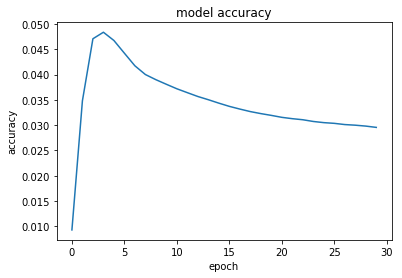

In [13]:
plt.plot(history.history['acc'])
#plt.plot(history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')

### view dev set

In [14]:
df_dev.head()

,brake,throttle,handwheelAngle,deriv_axCG,deriv_ayCG,deriv_pitchAngle,deriv_pitchRate,deriv_rollAngle,deriv_rollRate,deriv_vxCG,deriv_vyCG,deriv_wheelAccelFL,deriv_wheelAccelFR,deriv_wheelAccelRL,deriv_wheelAccelRR,deriv_yawAngle,deriv_yawRate
138700,0.0,28.5,-33.2,-0.48,2.91,-0.08,-2.09,0.04,5.73,0.01,0.06,3.44,-3.92,5.29,-0.26,-0.21,0.25
235093,0.0,0.9,-7.3,0.00,0.00,0.00,-0.09,0.01,0.75,0.00,0.00,0.00,0.10,0.10,0.08,0.00,0.17
54791,0.0,0.8,-33.1,0.00,-0.02,0.00,0.10,0.00,0.02,0.00,0.00,-0.49,0.10,-0.49,-0.15,0.00,0.23
11082,0.0,3.0,6.0,0.21,-0.07,-0.01,0.31,0.01,1.20,0.00,0.01,-0.10,0.40,-0.49,1.71,0.00,0.00
130051,0.0,4.7,-2.2,0.30,-3.06,0.04,1.21,0.04,1.70,-0.05,-0.02,-1.28,4.70,-11.57,10.76,-0.01,0.47


In [15]:
x_dev = tf.cast(df_dev[CS230.data.COLUMNS_HUMAN_INPUT].values, tf.float32)
y_dev = tf.cast(df_dev[CS230.data.COLUMNS_DERIV].values, tf.float32)

### predict against dev set

In [16]:
dev_predictions = model.predict(x_dev, steps=1)

In [17]:
dev_predictions

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.00099668, 0.00233278, 0.0019336 , ..., 0.00198931, 0.00476173,
        0.00109401],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], dtype=float32)

In [18]:
df_dev_predictions = pandas.DataFrame(dev_predictions, columns=CS230.data.COLUMNS_DERIV)
df_dev_predictions.head()

,deriv_axCG,deriv_ayCG,deriv_pitchAngle,deriv_pitchRate,deriv_rollAngle,deriv_rollRate,deriv_vxCG,deriv_vyCG,deriv_wheelAccelFL,deriv_wheelAccelFR,deriv_wheelAccelRL,deriv_wheelAccelRR,deriv_yawAngle,deriv_yawRate
0,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00
1,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00
2,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00
3,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00
4,3.874302e-07,0.000003,0.000002,0.000012,6.854534e-07,0.000015,0.000004,0.000031,3.278255e-07,0.000003,1.788139e-07,0.000002,0.000015,5.066395e-07


In [19]:
df_dev.head()

,brake,throttle,handwheelAngle,deriv_axCG,deriv_ayCG,deriv_pitchAngle,deriv_pitchRate,deriv_rollAngle,deriv_rollRate,deriv_vxCG,deriv_vyCG,deriv_wheelAccelFL,deriv_wheelAccelFR,deriv_wheelAccelRL,deriv_wheelAccelRR,deriv_yawAngle,deriv_yawRate
138700,0.0,28.5,-33.2,-0.48,2.91,-0.08,-2.09,0.04,5.73,0.01,0.06,3.44,-3.92,5.29,-0.26,-0.21,0.25
235093,0.0,0.9,-7.3,0.00,0.00,0.00,-0.09,0.01,0.75,0.00,0.00,0.00,0.10,0.10,0.08,0.00,0.17
54791,0.0,0.8,-33.1,0.00,-0.02,0.00,0.10,0.00,0.02,0.00,0.00,-0.49,0.10,-0.49,-0.15,0.00,0.23
11082,0.0,3.0,6.0,0.21,-0.07,-0.01,0.31,0.01,1.20,0.00,0.01,-0.10,0.40,-0.49,1.71,0.00,0.00
130051,0.0,4.7,-2.2,0.30,-3.06,0.04,1.21,0.04,1.70,-0.05,-0.02,-1.28,4.70,-11.57,10.76,-0.01,0.47


# experiment #2
- input: steering/brake/throttle
- output: discrete derivative x/y velocity

In [20]:
file_path = file_paths[0]
data_columns = CS230.data.COLUMNS_HUMAN_INPUT
label_columns = ['deriv_vxCG', 'deriv_vyCG']

train_percent = 0.9
dev_percent = 0.05
test_percent = 0.05

df = CS230.data.load(file_path)
df = CS230.data.stride_rows(df, stride=10)
df = CS230.data.add_derivatives(df, stride=1)
df = CS230.data.clean_discontinuities(df, stride=1)

df_train, df_dev, df_test = CS230.data.get_data_sets(df, train_percent, dev_percent, test_percent, 
                                                     data_columns, label_columns)

In [21]:
model = tf.keras.Sequential()

#model.add(tf.keras.layers.Dense(len(data_columns), activation='relu'))

model.add(tf.keras.layers.Dense(len(label_columns), activation='relu'))

#model.add(tf.keras.layers.Dropout(0.2))
#model.add(tf.keras.layers.Dense(len(label_columns), activation='relu'))

model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Dense(len(label_columns), activation='sigmoid'))

#optimizer = tf.train.AdamOptimizer(0.001)
optimizer = tf.keras.optimizers.SGD(lr=0.01, decay=1e-6, momentum=0.9, nesterov=True)

model.compile(
    optimizer=optimizer, 
    loss='mean_squared_error', 
    metrics=['accuracy']
)

In [22]:
x_train = tf.cast(df_train[data_columns].values, tf.float32)
y_train = tf.cast(df_train[label_columns].values, tf.float32)

In [23]:
history = model.fit(x_train, y_train, epochs=20, steps_per_epoch=100)

Epoch 1/20
100/100 [==============================] - 1s 9ms/step - loss: 0.3832 - acc: 0.6553
Epoch 2/20
100/100 [==============================] - 1s 6ms/step - loss: 0.1861 - acc: 0.6338
Epoch 3/20
100/100 [==============================] - 1s 6ms/step - loss: 0.0595 - acc: 0.6011
Epoch 4/20
100/100 [==============================] - 1s 6ms/step - loss: 0.0208 - acc: 0.5991
Epoch 5/20
100/100 [==============================] - 1s 6ms/step - loss: 0.0152 - acc: 0.5745
Epoch 6/20
100/100 [==============================] - 1s 6ms/step - loss: 0.0128 - acc: 0.5728
Epoch 7/20
100/100 [==============================] - 1s 6ms/step - loss: 0.0111 - acc: 0.5716
Epoch 8/20
100/100 [==============================] - 1s 6ms/step - loss: 0.0098 - acc: 0.5710
Epoch 9/20
100/100 [==============================] - 1s 6ms/step - loss: 0.0088 - acc: 0.5702
Epoch 10/20
100/100 [==============================] - 1s 6ms/step - loss: 0.0080 - acc: 0.5696
Epoch 11/20
100/100 [============================

Text(0.5, 0, 'epoch')

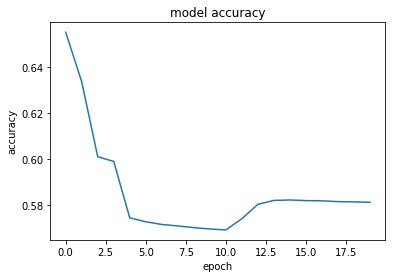

In [24]:
plt.plot(history.history['acc'])
#plt.plot(history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')

In [25]:
x_dev = tf.cast(df_dev[data_columns].values, tf.float32)
y_dev = tf.cast(df_dev[label_columns].values, tf.float32)

In [26]:
dev_predictions = model.predict(x_dev, steps=1)

In [27]:
df_dev_predictions = pandas.DataFrame(dev_predictions, columns=label_columns)

In [28]:
df_dev.head()

,brake,throttle,handwheelAngle,deriv_vxCG,deriv_vyCG
83250,0.0,0.8,-33.0,0.00,-0.01
24620,0.0,0.7,-33.0,0.00,0.00
169855,0.0,1.0,-97.5,-0.04,0.02
105728,0.0,0.4,15.9,-0.01,-0.01
70791,0.0,0.8,-33.1,-0.01,0.00


In [29]:
df_dev_predictions.head()

,deriv_vxCG,deriv_vyCG
0,0.000000,0.000000
1,0.100679,0.101632
2,0.000000,0.000000
3,0.000000,0.000000
4,0.000000,0.000000
